## Pergunta 2 — Média de Passageiros por Hora em Maio de 2023

**Pergunta:** Qual foi a quantidade média de passageiros por hora do dia em Maio de 2023?

**Fonte de dados:** Delta Table `ifood_taxi_case.taxi_gold` (Camada de consumo do Lakehouse).

### a) Setup

In [0]:
%load_ext autoreload
%autoreload 2

import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.config.settings import Tables

print(f"Tabela: {Tables.SCHEMA}.{Tables.GOLD_TAXI}")

Tabela: ifood_taxi_case.taxi_gold


### b) Critérios de Filtro: `passenger_count > 0` e `month = 5`

- **`passenger_count > 0`:** O filtro remove ~161k corridas em Maio (4,6% das 3,5MM de Maio):
  - ~102k com `passenger_count NULL` — batch sistêmico distribuído ao longo de Jan–Mai onde o fornecedor
    TPEP não transmitiu campos secundários (2,66% do total geral de 16M registros, não exclusivo de Maio).
  - ~60k com `passenger_count = 0` — motorista registrou corrida sem passageiro (1,7% de Maio).

Ambos introduziriam viés que impactam para baixo a média — as corridas têm âncora temporal e valor financeiro válidos, mas não informam quantos passageiros estavam no veículo.

- **`month = 5`:** A pergunta é específica para Maio de 2023. A Gold mantém todos os meses (Jan–Mai)
  para preservar a base completa — o filtro de mês pertence à query de análise, não à camada.

- **`pickup_hour`:** Derivado de `tpep_pickup_datetime` via `F.hour()` na camada Gold, disponível
  diretamente para agregação sem transformação adicional.

In [0]:
%sql
SELECT
    pickup_hour,
    ROUND(AVG(passenger_count), 4) AS avg_passengers,
    COUNT(*)                        AS total_trips
FROM ifood_taxi_case.taxi_gold
WHERE passenger_count > 0
  AND month = 5
GROUP BY pickup_hour
ORDER BY pickup_hour

pickup_hour,avg_passengers,total_trips
0,1.4272,88696
1,1.4377,57614
2,1.455,37093
3,1.4522,24145
4,1.4049,15778
5,1.2837,18241
6,1.2612,45498
7,1.2819,91802
8,1.2957,125500
9,1.312,140924


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


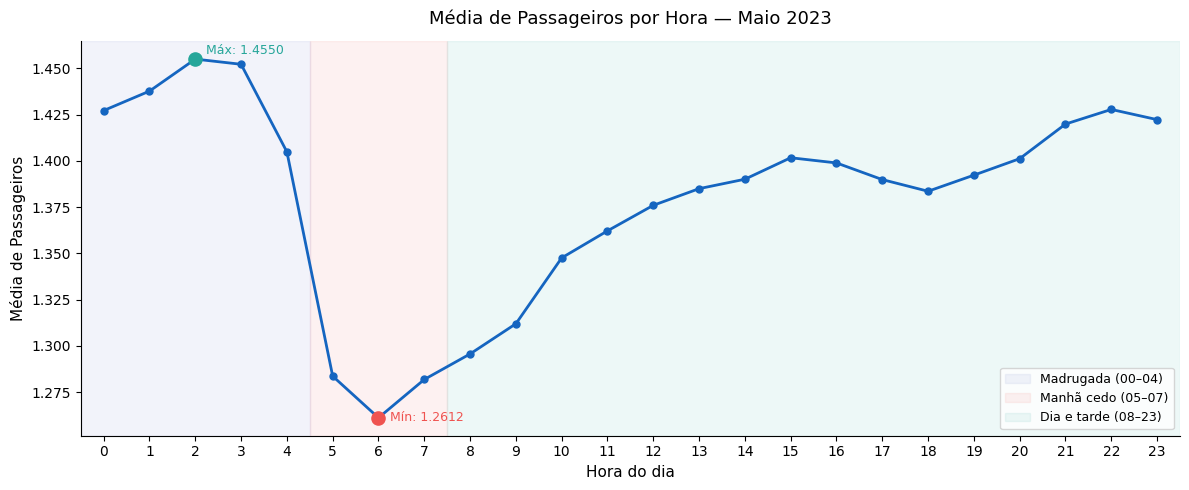

In [0]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

df_plot = spark.sql("""
    SELECT
        pickup_hour,
        ROUND(AVG(passenger_count), 4) AS avg_passengers
    FROM ifood_taxi_case.taxi_gold
    WHERE passenger_count > 0
      AND month = 5
    GROUP BY pickup_hour
    ORDER BY pickup_hour
""").toPandas()

hours = df_plot["pickup_hour"]
avgs  = df_plot["avg_passengers"]

fig, ax = plt.subplots(figsize=(12, 5))

ax.axvspan(-0.5,  4.5, alpha=0.08, color="#5C6BC0", label="Madrugada (00–04)")
ax.axvspan( 4.5,  7.5, alpha=0.08, color="#EF5350", label="Manhã cedo (05–07)")
ax.axvspan( 7.5, 23.5, alpha=0.08, color="#26A69A", label="Dia e tarde (08–23)")

ax.plot(hours, avgs, marker="o", color="#1565C0", linewidth=2, markersize=5)

idx_min = avgs.idxmin()
idx_max = avgs.idxmax()
ax.scatter(hours[idx_min], avgs[idx_min], color="#EF5350", s=90, zorder=5)
ax.scatter(hours[idx_max], avgs[idx_max], color="#26A69A", s=90, zorder=5)
ax.annotate(f"Mín: {avgs[idx_min]:.4f}", (hours[idx_min], avgs[idx_min]),
            textcoords="offset points", xytext=(8, -2), fontsize=9, color="#EF5350")
ax.annotate(f"Máx: {avgs[idx_max]:.4f}", (hours[idx_max], avgs[idx_max]),
            textcoords="offset points", xytext=(8, 4),  fontsize=9, color="#26A69A")

ax.set_title("Média de Passageiros por Hora — Maio 2023", fontsize=13, pad=12)
ax.set_xlabel("Hora do dia", fontsize=11)
ax.set_ylabel("Média de Passageiros", fontsize=11)
ax.set_xticks(range(0, 24))
ax.set_xlim(-0.5, 23.5)
ax.legend(loc="lower right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### c) Resultado e Interpretação

A query retorna a média de passageiros por hora (0–23) em Maio de 2023. Padrão observado:

- **Madrugada (00–04):** `maior média` (~1,43–1,46 pass./corrida) — corridas compartilhadas após eventos noturnos.
- **Manhã cedo (05–07):** `menor média` do dia (~1,26–1,28) — pico de commuters solo para o trabalho.
- **Dia e tarde (08–23):** `recuperação` gradual (~1,30 → ~1,44) com aumento de corridas de lazer e grupos.

O padrão é consistente com o perfil de mobilidade urbana de Nova York: a madrugada concentra
deslocamentos em grupo, enquanto o rush matinal é dominado por passageiros individuais.

> **Visualização:** No Databricks, ao executar a célula `%sql`, selecione a aba "+" → **Line Chart**
> com `pickup_hour` no eixo X e `avg_passengers` no eixo Y para visualizar a curva horária.